# Benchmark: Specialized Paths (1D, 2D, 3D) vs. Generic Fallback Path
This notebook benchmarks the performance savings of having specialized unrolled paths for 1D, 2D, and 3D charge deposition compared to a generic multidimensional fallback path (which uses loops over dimensions and corners).

Both versions share the same optimizations (early extent masking and contiguous coordinate unpacking), so this specifically measures the impact of unrolling the loops and specialized indexing.

In [1]:
import sys
import os
import time
import math
import itertools
from typing import Sequence
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

repo_root = os.path.abspath(".")
if repo_root not in sys.path:
    sys.path.append(repo_root)

import cheetah.utils.cloud_in_cell as cic_tensor

device_types = ["cpu"]
if torch.backends.mps.is_available():
    device_types.append("mps")
if torch.cuda.is_available():
    device_types.append("cuda")
print(f"Devices: {device_types}")

def sync(device):
    if device.type == "mps":
        torch.mps.synchronize()
    elif device.type == "cuda":
        torch.cuda.synchronize()

Devices: ['cpu', 'mps']


In [2]:
def cloud_in_cell_generic_only(
    positions: torch.Tensor,
    bins: int | Sequence[int],
    extent: torch.Tensor | None = None,
    charges: torch.Tensor | None = None,
) -> torch.Tensor:
    if extent is None:
        extent = torch.stack([positions.amin(dim=-2), positions.amax(dim=-2)], dim=-1)
    if charges is None:
        charges = torch.ones_like(positions[..., 0])

    num_hist_dims = positions.shape[-1]
    histogram_shape = [bins] * num_hist_dims if isinstance(bins, int) else bins
    assert (
        len(histogram_shape) == num_hist_dims
    ), "Number of bin values must match number of position dimensions."

    vector_shape = positions.shape[:-2]
    num_histogram_bins = math.prod(histogram_shape)
    flat_charge_grid = positions.new_zeros(*vector_shape, num_histogram_bins)

    # Generic path (copied from cloud_in_cell fallback)
    in_extent = torch.ones_like(charges, dtype=torch.bool)
    for d in range(num_hist_dims):
        coord = positions[..., d]
        lim0 = extent[..., d, 0].unsqueeze(-1)
        lim1 = extent[..., d, 1].unsqueeze(-1)
        in_extent = in_extent & (coord >= lim0) & (coord <= lim1)

    masked_charges = charges * in_extent

    idx_dims = []
    frac_dims = []
    for d in range(num_hist_dims):
        coord = positions[..., d].contiguous()
        lim0 = extent[..., d, 0].unsqueeze(-1)
        lim1 = extent[..., d, 1].unsqueeze(-1)
        Nd = histogram_shape[d]
        dd = (lim1 - lim0) / Nd
        u = (coord - lim0) / dd - 0.5

        idx = u.floor().long()
        frac = u - idx

        idx_dims.append(idx)
        frac_dims.append(frac)

    strides = [math.prod(histogram_shape[d + 1 :]) for d in range(num_hist_dims)]

    for corner in itertools.product([0, 1], repeat=num_hist_dims):
        corner_idx = 0
        corner_weight = masked_charges.clone()
        for d in range(num_hist_dims):
            use_right = corner[d]
            idx = idx_dims[d] + use_right
            idx_clamped = idx.clamp(0, histogram_shape[d] - 1)
            corner_idx = corner_idx + idx_clamped * strides[d]

            mask = (idx >= 0) & (idx < histogram_shape[d])
            weight_factor = (frac_dims[d] if use_right else (1.0 - frac_dims[d])) * mask
            corner_weight = corner_weight * weight_factor

        flat_charge_grid.scatter_add_(dim=-1, index=corner_idx, src=corner_weight)

    charge_grid = flat_charge_grid.reshape(*vector_shape, *histogram_shape)
    return charge_grid

In [3]:
def setup_benchmark_inputs(dims, batch_shape, num_particles, bins, device):
    torch.manual_seed(42)
    coords = [torch.rand(*batch_shape, num_particles, device=device) * 1.8 - 0.9 for _ in range(dims)]
    positions = torch.stack(coords, dim=-1)
    charges = torch.rand(*batch_shape, num_particles, device=device)
    
    # Calculate equivalent extents
    extent_list = []
    histogram_shape = [bins] * dims if isinstance(bins, int) else bins
    for d in range(dims):
        Nd = histogram_shape[d]
        dd = 2.0 / (Nd - 1)
        extent_list.append([-1.0 - dd/2.0, 1.0 + dd/2.0])
    extent = torch.tensor(extent_list, device=device)
    
    return positions, histogram_shape, extent, charges

In [4]:
for d in [1, 2, 3]:
    pos, bins, ext, chg = setup_benchmark_inputs(d, (2, 5), 100, 10, torch.device("cpu"))
    out_spec = cic_tensor.cloud_in_cell_charge_deposition(pos, bins, ext, chg)
    out_gen = cloud_in_cell_generic_only(pos, bins, ext, chg)
    diff = torch.max(torch.abs(out_spec - out_gen))
    print(f"{d}D - Max Difference: {diff.item():.2e}")

1D - Max Difference: 0.00e+00
2D - Max Difference: 2.38e-07
3D - Max Difference: 1.19e-07


In [5]:
def run_benchmark(num_runs=10):
    results = []
    num_particles = 100000
    batch_shape = (20, 1)
    
    test_cases = [
        (1, 150, "1D"),
        (2, 150, "2D"),
        (3, 50, "3D"),
    ]
    
    for device_name in device_types:
        device = torch.device(device_name)
        for dims, bins, label in test_cases:
            pos, bins_shape, ext, chg = setup_benchmark_inputs(dims, batch_shape, num_particles, bins, device)
            
            # Warmups
            for _ in range(3):
                _ = cic_tensor.cloud_in_cell_charge_deposition(pos, bins_shape, ext, chg)
                _ = cloud_in_cell_generic_only(pos, bins_shape, ext, chg)
            sync(device)
            
            # Specialized Run
            t_spec = []
            for _ in range(num_runs):
                t0 = time.perf_counter()
                _ = cic_tensor.cloud_in_cell_charge_deposition(pos, bins_shape, ext, chg)
                sync(device)
                t_spec.append(time.perf_counter() - t0)
                
            # Generic Run
            t_gen = []
            for _ in range(num_runs):
                t0 = time.perf_counter()
                _ = cloud_in_cell_generic_only(pos, bins_shape, ext, chg)
                sync(device)
                t_gen.append(time.perf_counter() - t0)
                
            results.append({
                "Device": device_name.upper(),
                "Dimension": label,
                "Specialized (s)": np.mean(t_spec),
                "Generic Fallback (s)": np.mean(t_gen),
                "Speedup": np.mean(t_gen) / np.mean(t_spec)
            })
            
    df = pd.DataFrame(results)
    return df

df_res = run_benchmark()
df_res

,Device,Dimension,Specialized (s),Generic Fallback (s),Speedup
0,CPU,1D,0.015124,0.016823,1.112320
1,CPU,2D,0.041609,0.068159,1.638066
2,CPU,3D,0.079188,0.190174,2.401552
3,MPS,1D,0.129890,0.129430,0.996454
4,MPS,2D,0.017263,0.020507,1.187882
5,MPS,3D,0.030452,0.046327,1.521299


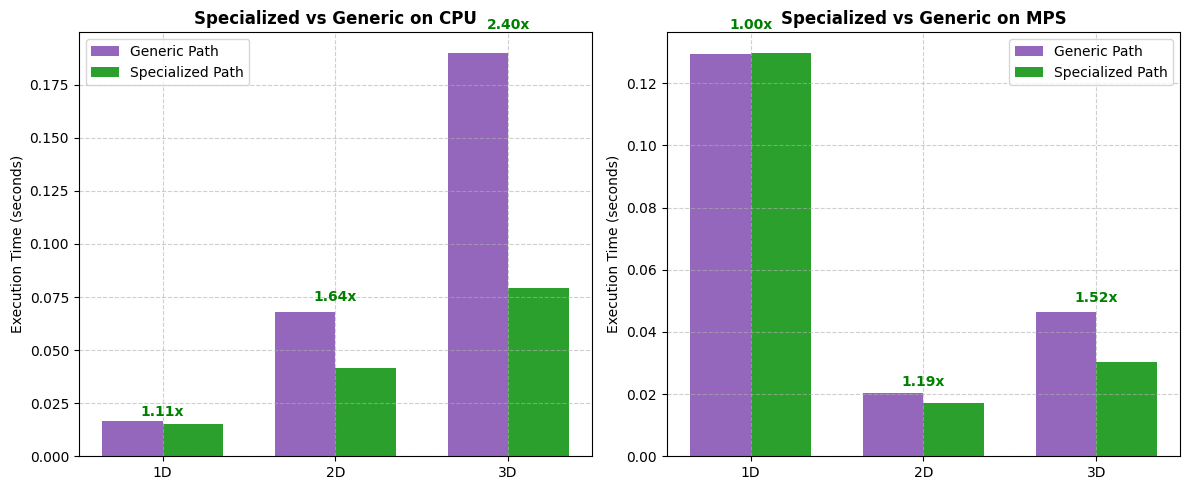

In [6]:
def plot_comparison(df):
    devices = df["Device"].unique()
    dims = df["Dimension"].unique()
    
    fig, axes = plt.subplots(1, len(devices), figsize=(6 * len(devices), 5), squeeze=False)
    
    for idx, dev in enumerate(devices):
        ax = axes[0, idx]
        sub_df = df[df["Device"] == dev]
        
        x = np.arange(len(dims))
        width = 0.35
        
        rects1 = ax.bar(x - width/2, sub_df["Generic Fallback (s)"], width, label="Generic Path", color="#9467bd")
        rects2 = ax.bar(x + width/2, sub_df["Specialized (s)"], width, label="Specialized Path", color="#2ca02c")
        
        ax.set_title(f"Specialized vs Generic on {dev}", fontsize=12, fontweight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(dims)
        ax.set_ylabel("Execution Time (seconds)")
        ax.legend()
        ax.grid(True, linestyle="--", alpha=0.6)
        
        # Add speedup label on top of bars
        for i, val in enumerate(sub_df["Speedup"]):
            ax.text(i, max(sub_df["Generic Fallback (s)"].iloc[i], sub_df["Specialized (s)"].iloc[i]) * 1.05,
                    f"{val:.2f}x", ha="center", va="bottom", color="green", fontweight="bold")
            
    plt.tight_layout()
    plt.savefig("specialized_paths_comparison.png", dpi=300)
    plt.show()

plot_comparison(df_res)